# Tiny Dreamer Highway — Discrete Baseline Run

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

This notebook validates the full DreamerV1 training pipeline using **discrete actions** (DiscreteMetaAction: LANE_LEFT, IDLE, LANE_RIGHT, FASTER, SLOWER). Discrete control is significantly easier than continuous control, making it the ideal first test to confirm the world model, imagination rollouts, and actor-critic learning are all working correctly before attempting the harder continuous problem.

## Strategy

1. Mount Google Drive and clone/pull the repo.
2. Install the package.
3. Load the discrete training config (`discrete_training_run.yaml`).
4. Run training — the `DiscreteActor` uses Gumbel-Softmax for differentiable imagination.
5. Evaluate the trained agent and record demo GIFs.
6. If discrete works well, move on to continuous control with confidence.

In [6]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'
WORKTREE = Path('/content/CSC_580_Final_Project')

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

print('Drive root:', DRIVE_ROOT)
print('Artifact root:', ARTIFACT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/CSC_580_Final_Project
Artifact root: /content/drive/MyDrive/CSC_580_Final_Project/artifacts


In [ ]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
BRANCH='main'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone -b "${BRANCH}" "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git fetch origin "${BRANCH}"
  git checkout "${BRANCH}"
  git pull --ff-only origin "${BRANCH}"
fi
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

Your branch is up to date with 'origin/main'.
Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main -> FETCH_HEAD
Already on 'main'
From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main -> FETCH_HEAD


## Load Discrete Config

We use `discrete_training_run.yaml` which sets `action.type: discrete` and
`action.num_actions: 5` for the standard highway-env DiscreteMetaAction space.

In [ ]:
import json
import sys
import torch
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'notebooks' / 'configs' / 'discrete_experiment.yaml'
config = load_experiment_config(CONFIG_PATH)

print('Loaded config from:', CONFIG_PATH)
print('Action type:', config.env.action.type)
print('Num discrete actions:', config.env.action.num_actions)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')
print('Batch size:', config.training.batch_size)
print('Cycles:', config.training.cycles)
print('World-model updates/cycle:', config.training.world_model_updates_per_cycle)
print('Behavior updates/cycle:', config.training.behavior_updates_per_cycle)
print('Evaluation every', config.evaluation.interval, 'cycles,', config.evaluation.episodes, 'episodes')

Loaded config from: /content/CSC_580_Final_Project/examples/discrete_experiment.yaml
Action type: discrete
Num discrete actions: 5
GPU: NVIDIA A100-SXM4-40GB
Batch size: 4
Cycles: 10
World-model updates/cycle: 1
Behavior updates/cycle: 1
Evaluation every 0 cycles, 0 episodes


In [9]:
# Verify stability / optimisation knobs before launching
print("grad_clip_norm:", config.training.grad_clip_norm)
print("lr_warmup_steps:", config.training.lr_warmup_steps)
print("use_amp:", getattr(config.training, "use_amp", False))
print("amp_dtype:", getattr(config.training, "amp_dtype", None))
print("sequence_length:", config.replay.sequence_length)
print("batch_size:", config.training.batch_size)

grad_clip_norm: 100.0
lr_warmup_steps: 0
use_amp: False
amp_dtype: bfloat16
sequence_length: 8
batch_size: 4


In [10]:
RUN_NAME = 'discrete_baseline_001'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

# Override these to shorten/extend runs without editing the YAML
CYCLES = 1000              # None → use YAML default (500)
WARM_START_STEPS = 2048    # None → use YAML default (2048)
POLICY_STEPS = None        # None → use YAML default (64)
CHECKPOINT_INTERVAL = None
RESUME_FROM = None

effective_cycles = config.training.cycles if CYCLES is None else CYCLES
effective_warm = config.training.warm_start_steps if WARM_START_STEPS is None else WARM_START_STEPS
print('Run name:', RUN_NAME)
print('Effective cycles:', effective_cycles)
print('Effective warm-start steps:', effective_warm)

Run name: discrete_baseline_001
Effective cycles: 1000
Effective warm-start steps: 2048


In [11]:
print(f'Launching discrete baseline run ({config.env.action.type} action).')
print('Per-cycle progress lines will appear below.\n')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('\nCompleted cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching discrete baseline run (discrete action).
Per-cycle progress lines will appear below.

[train] starting run | cycles=1000 | start_step=1 | warm_start_steps=2048 | policy_steps=8 | device=cpu
[train] step=1/1000 | warm=2048 | policy=8 | replay=2056 | world_total=8597.5586 | actor=0.9656 | critic=2.6085 | eval_reward=n/a | cycle_s=60.3 | elapsed_s=60.3 | checkpoint=-
[train] step=2/1000 | warm=0 | policy=8 | replay=2064 | world_total=9050.5410 | actor=0.2471 | critic=2.1533 | eval_reward=n/a | cycle_s=0.8 | elapsed_s=61.1 | checkpoint=-
[train] step=3/1000 | warm=0 | policy=8 | replay=2072 | world_total=6184.3721 | actor=0.4109 | critic=2.4340 | eval_reward=n/a | cycle_s=0.8 | elapsed_s=62.0 | checkpoint=-
[train] step=4/1000 | warm=0 | policy=8 | replay=2080 | world_total=5017.7256 | actor=0.3781 | critic=1.8814 | eval_reward=n/a | cycle_s=0.8 | elapsed_s=62.8 | checkpoint=-
[train] step=5/1000 | warm=0 | policy=8 | replay=2088 | world_total=4584.3799 | actor=0.6933 | critic=2.

## Training History Analysis

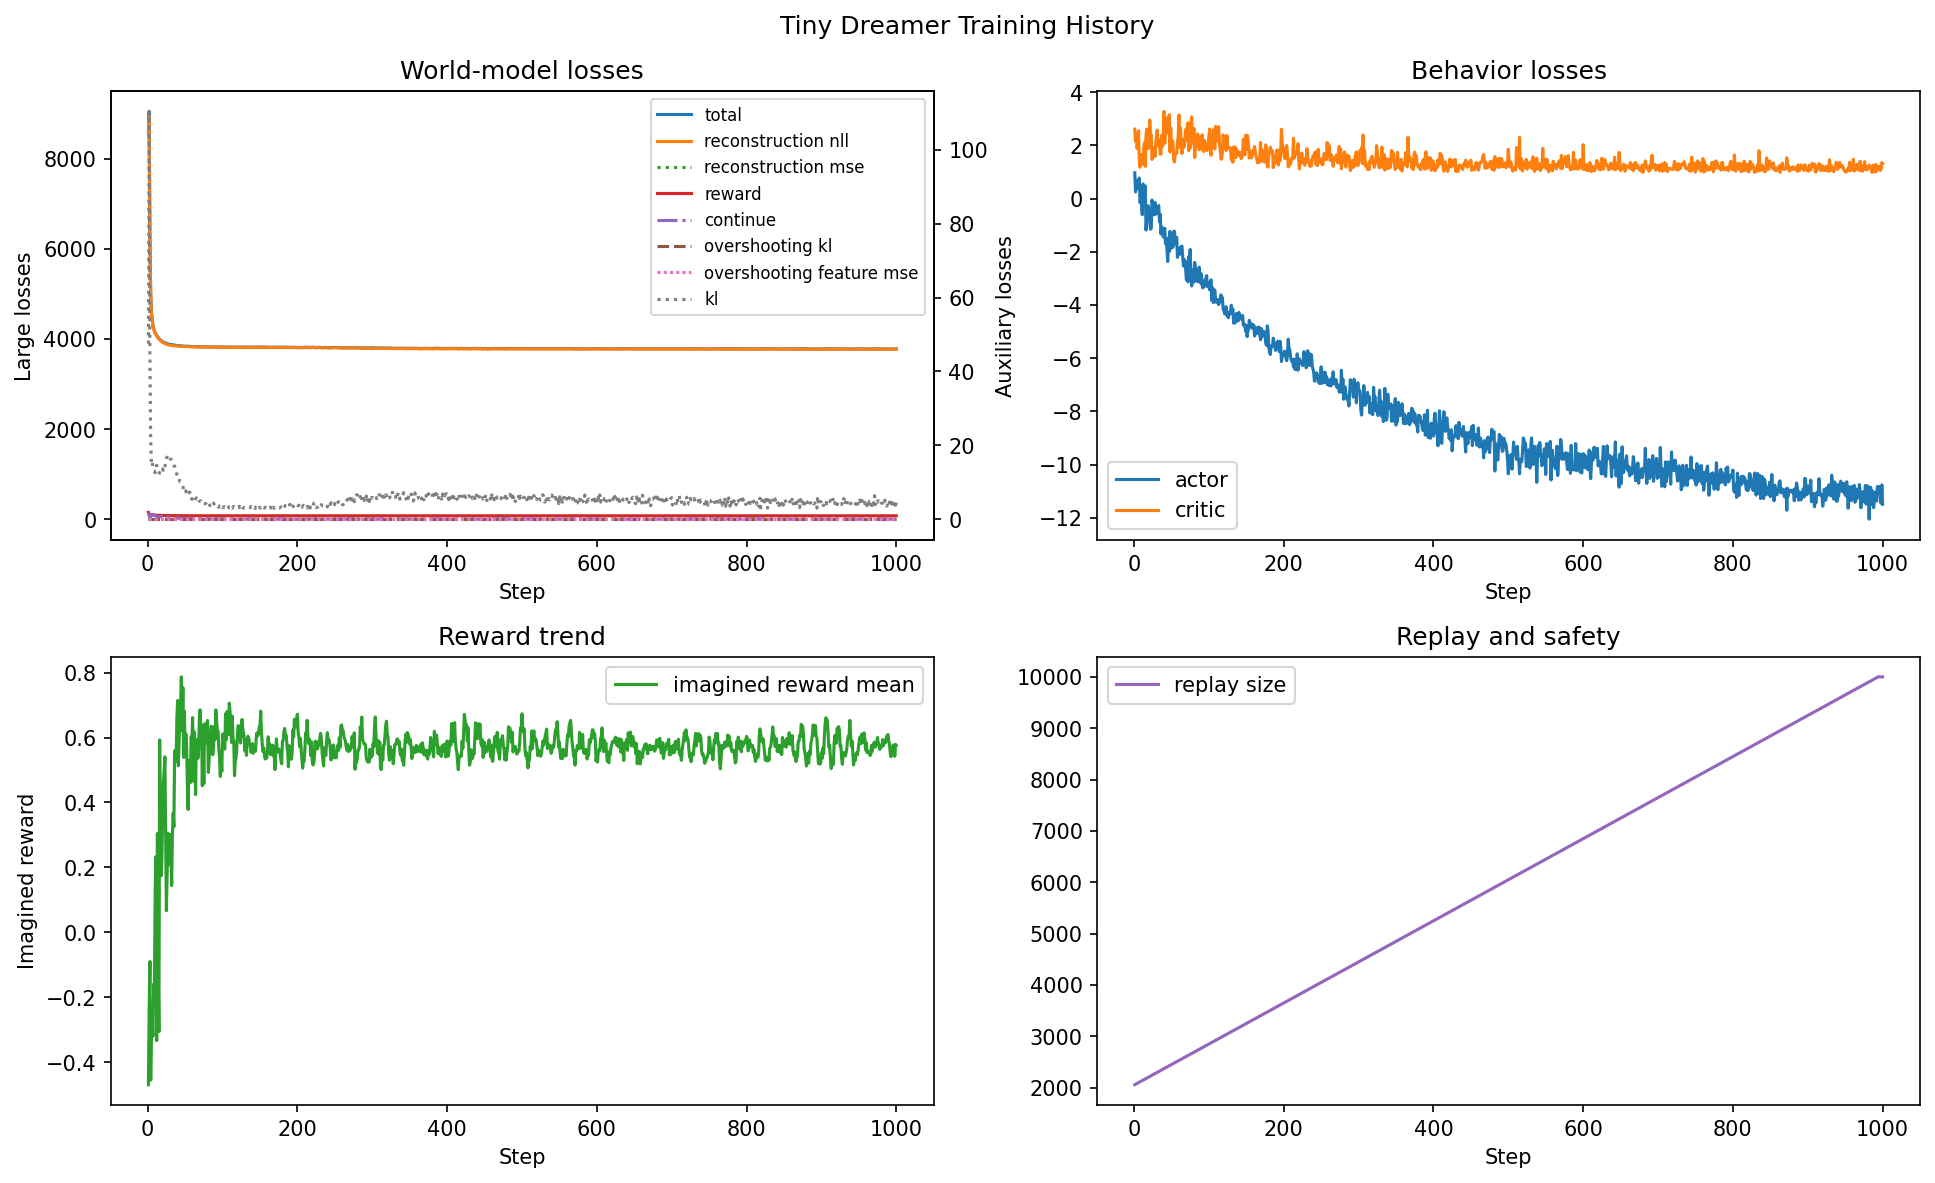

{'analysis_summary': {'best_imagined_reward_mean': 0.786713719367981,
  'best_imagined_reward_step': 45,
  'best_world_model_step': 894,
  'best_world_model_total_loss': 3775.80078125,
  'largest_replay_size': 10000,
  'largest_replay_step': 994,
  'last_metrics': {'behavior/actor_loss': -11.490126609802246,
   'behavior/critic_loss': 1.3149338960647583,
   'behavior/imagined_reward_mean': 0.5756322741508484,
   'behavior/imagined_value_mean': 10.810726165771484,
   'policy_added': 8,
   'replay_size': 10000,
   'step': 1000,
   'warm_start_added': 0,
   'world_model/continue_loss': 0.0020447499118745327,
   'world_model/kl_loss': 4.587697505950928,
   'world_model/kl_loss_raw': 4.587697505950928,
   'world_model/observation_log_prob': -3775.337646484375,
   'world_model/overshooting_feature_mse': 0.0,
   'world_model/overshooting_kl_loss': 0.0,
   'world_model/overshooting_pairs': 0.0,
   'world_model/reconstruction_loss': 3775.337646484375,
   'world_model/reconstruction_mse': 0.0055

In [12]:
from IPython.display import Image, display
import csv
import importlib
import json
import tiny_dreamer_highway.evaluation.training_analysis as training_analysis

training_analysis = importlib.reload(training_analysis)
export_training_history_artifacts = training_analysis.export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_summary = json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))
with (training_summary.log_dir / 'cycle_metrics.csv').open('r', encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
latest_metrics_row = metric_rows[-1]
{
    'analysis_summary': analysis_summary,
    'key_metrics': {
        'world_model/reconstruction_loss': latest_metrics_row.get('world_model/reconstruction_loss'),
        'world_model/reconstruction_mse': latest_metrics_row.get('world_model/reconstruction_mse'),
        'evaluation/mean_reward': latest_metrics_row.get('evaluation/mean_reward'),
        'evaluation/crash_rate': latest_metrics_row.get('evaluation/crash_rate'),
    },
}

## Agent Driving Demo

Record agent-driving GIFs using the trained discrete-action policy.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/3 | steps=51 | reward=28.33 | OK | saved discrete_baseline_001_ep01.gif
[demo] episode 2/3 | steps=51 | reward=28.33 | OK | saved discrete_baseline_001_ep02.gif
[demo] episode 3/3 | steps=51 | reward=28.33 | OK | saved discrete_baseline_001_ep03.gif
[demo] done | avg_reward=28.33 | summary=discrete_baseline_001_summary.json

discrete_baseline_001_ep01.gif


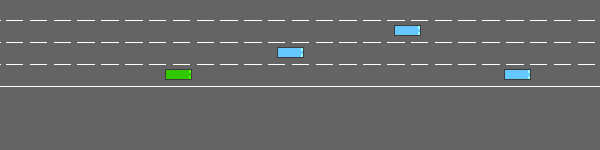


discrete_baseline_001_ep02.gif


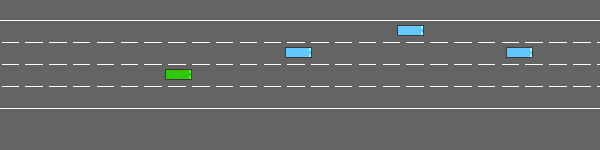


discrete_baseline_001_ep03.gif


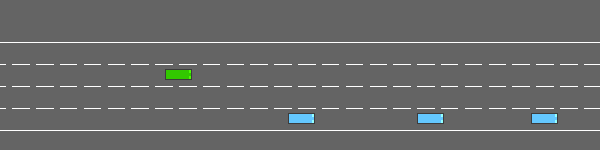

In [13]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=3,
    max_steps=1000,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))

## Next Steps

If the discrete agent survives and accumulates positive reward:
1. Check the demo GIFs — does it change lanes, speed up, avoid collisions?
2. Compare world model loss curves — is reconstruction improving?
3. If yes → move to continuous control (`training_run.yaml`) with confidence that the pipeline works.